<div class="alert alert-block" style="background-color: #51585eff; border-color: #42474aff; color: white;">
<center> <h1> Syntravel - Travel Diaries Generation </h1> </center> <br>
<center> <h2> Transferability </h2></center>


# Table of Contents

**1. [Importing Libraries and Loading Data](#importing-libraries-and-data)**  
   - [1.1 Importing Libraries](#importing-libraries)  
   - [1.2 Loading and Reading Data](#loading-and-reading-data)  

**2. [Internal Transferability](#internal)**
   - [2.1 Utrecht ](#utrecht)  
   - [2.2 Friesland](#Friesland)
   - [2.3 Results Analysis](#results)

**3. [External Transferability](#external)**
   - [3.1 Portguese Travel Diaries Generation](#gene)  
   - [3.2 Results EDA](#eda)
  

# 1. Importing Libraries and Loading Data  <a class="anchor" id="importing-libraries-and-data"></a>


## 1.1. Importing Libraries <a class="anchor" id="importing-libraries"></a>

In [ ]:
import os
if not os.path.isdir('llm_config'):
    os.chdir('..')

import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter
import collections

#Geospatial Libraries
import geopandas as gpd
import osmnx as ox

#Importing Functions
from Helpers.evaluation import *
from Helpers.trajectory_generation_portugal import *
from Helpers.cot_patterns import *
from Helpers.visualizations.fig_transferability import *
from Helpers.trajectory_generation_rural import * 
from Helpers.visualizations.viz_utils import prep_syntrav_run


## 1.2. Loading and Reading Data <a class="anchor" id="loading-and-reading-data"></a>

In [2]:
odin_train = pd.read_csv("ODiN (DATA)/DATAVERSE/intermediarie_csvs/odin_train.csv")
geo_df = pd.read_csv("ODiN (DATA)/DATAVERSE/ODiN Data (RAW)/geonames-postal-code@public.csv", sep=";")

C:\Users\X1605\AppData\Local\Temp\ipykernel_1192\2247926964.py:1: DtypeWarning: Columns (0: Number of people in household, 1: Trip distance in the Netherlands (in hectometers), 2: Trip duration in the Netherlands (in minutes)) have mixed types. Specify dtype option on import or set low_memory=False.
  odin_train = pd.read_csv("ODiN (DATA)/DATAVERSE/intermediarie_csvs/odin_train.csv")


In [3]:
geo_lookup   = build_geo_lookup(geo_df)
#urban_lookup = build_urbanisation_lookup(odin_train)

In [4]:
def load_multiple(paths):
      all_records = []
      for p in paths:
          all_records.extend(load_syn_records(p))
      return all_records

syn_weekday = load_multiple(["Json_files/variance/full_seed42.json"])

In [5]:
with open("Json_files/persona_objects.json") as f:
      persona_objects = json.load(f)

In [6]:
with open('Json_files/cot_results.json', encoding='utf-8') as f:
      cot_results = json.load(f)                                                                                       

patterns = extract_final_patterns(cot_results)

In [7]:
real = pd.read_csv(
      r"ODiN (DATA)/DATAVERSE/intermediarie_csvs/odin_holdout.csv",
      low_memory=False,
  )
real = prepare_real_trips(real)
real_weekday = real[real["DayType"] == "weekday"]

In [8]:
# Aply the zero-trip correction to the real data, based on the ratio of zero-trip respondents in the ODiN survey.
resp = pd.read_csv(r"ODiN (DATA)/DATAVERSE/ODiN Data (RAW)/Respondents.csv", low_memory=False)
resp_weekday = resp[resp['Weekdag'].isin([1,2,3,4,5])]
n_real_zero_trip = round(
      (resp_weekday['AantVpl'] == 0).sum()
      * real_weekday['Person_index'].nunique()
      / (resp_weekday['AantVpl'] > 0).sum()
  )
print(f"Zero-trip correction: {n_real_zero_trip} persons")

Zero-trip correction: 1005 persons


In [9]:
# loading baseline evaluation results   
_smp = pd.read_csv(Path("smp/results/smp_evaluation_results.csv")).set_index(["label", "metric"])["value"]

In [10]:
def smp_row(label, city):
      return {k: _smp.loc[(label, k)] for k in ["SD", "SI", "DARD", "DailyLoc"]}

metrics = ["SD", "SI", "DARD", "DailyLoc"]

In [11]:
all_real = pd.read_csv(r"ODiN (DATA)/DATAVERSE/intermediarie_csvs/odin_cleaned.csv", low_memory=False)
all_real = prepare_real_trips(all_real)
all_real_weekday = all_real[all_real["DayType"] == "weekday"]

# 2. Internal Transferability <a class="anchor" id="internal"></a>

In [12]:
_smp_seeds = pd.read_csv("smp/results/seeds_summary.csv").set_index(["label", "metric"])

def smp_row_seeded(label):
    mean = {k: _smp_seeds.loc[(label, k), "mean"] for k in metrics}
    std  = {k: _smp_seeds.loc[(label, k), "std"]  for k in metrics}
    return mean, std

smp_utrecht_mean, smp_utrecht_std     = smp_row_seeded("holdout_utrecht")
smp_friesland_mean, smp_friesland_std = smp_row_seeded("holdout_friesland")

In [13]:
# Filter real holdout by province
real_utrecht   = real_weekday[real_weekday["Province of residential municipality"] == "Utrecht"]
real_friesland = real_weekday[real_weekday["Province of residential municipality"] == "Friesland"]

print(f"Utrecht trips:   {len(real_utrecht)}")
print(f"Friesland trips: {len(real_friesland)}")

Utrecht trips:   12602
Friesland trips: 2546


In [14]:
TRANSFER_SEEDS = [3, 7, 13, 27, 42]

def multi_seed_scores(real_df, label_prefix):
      rows = []
      for seed in TRANSFER_SEEDS:
          syn = load_multiple([f"Json_files/variance/full_seed{seed}.json"])
          s = evaluate(real_df, syn, label=f"{label_prefix}_seed{seed}", n_real_zero_trip=n_real_zero_trip)
          rows.append({"seed": seed, **{k: s[k] for k in metrics}})
      return pd.DataFrame(rows).set_index("seed")

In [15]:
# Get Utretch scores
utrecht_seed_scores = multi_seed_scores(real_utrecht, "utrecht")
scores_utrecht      = utrecht_seed_scores.mean().to_dict()
scores_utrecht_std  = utrecht_seed_scores.std().to_dict()

In [16]:
## Get Friesland Scores 
friesland_seed_scores = multi_seed_scores(real_friesland, "friesland")
scores_friesland      = friesland_seed_scores.mean().to_dict()
scores_friesland_std  = friesland_seed_scores.std().to_dict()

## 2.1. Utrecht Results <a class="anchor" id="utrecht"></a>

In [17]:
smp_utrecht = smp_row("holdout_utrecht", "Utrecht")

mean_row = {"City": "Utrecht", "Model": "LLM (Full)",   **{k: scores_utrecht[k] for k in metrics}}
smp_row_ = {"City": "Utrecht", "Model": "SMP baseline", **smp_utrecht}

num_df = pd.DataFrame([mean_row, smp_row_]).set_index(["City", "Model"])
mask   = num_df.apply(lambda col: ["font-weight: bold; color: green" if v == col.min() else "" for v in col])

df = num_df.astype(object).copy()
for k in metrics:
      df.loc[("Utrecht", "LLM (Full)"),   k] = f"{scores_utrecht[k]:.4f} ± {scores_utrecht_std[k]:.4f}"
      df.loc[("Utrecht", "SMP baseline"), k] = f"{smp_utrecht_mean[k]:.4f} ± {smp_utrecht_std[k]:.4f}"

df.style\
    .apply(lambda col: mask[col.name], axis=0)\
    .set_caption("Transferability — Holdout Provinces (JSD, lower is better; LLM = mean ± std over 5 seeds)")

## 2.2. Friesland Results <a class="anchor" id="Friesland"></a>

In [18]:
smp_friesland = smp_row("holdout_friesland", "Friesland")

mean_row = {"City": "Friesland", "Model": "LLM (Full)",   **{k: scores_friesland[k] for k in metrics}}
smp_row_ = {"City": "Friesland", "Model": "SMP baseline", **smp_friesland}

num_df = pd.DataFrame([mean_row, smp_row_]).set_index(["City", "Model"])
mask   = num_df.apply(lambda col: ["font-weight: bold; color: green" if v == col.min() else "" for v in col])

df = num_df.astype(object).copy()
for k in metrics:
      df.loc[("Friesland", "LLM (Full)"),   k] = f"{scores_friesland[k]:.4f} ± {scores_friesland_std[k]:.4f}"
      df.loc[("Friesland", "SMP baseline"), k] = f"{smp_friesland_mean[k]:.4f} ± {smp_friesland_std[k]:.4f}"

df.style\
    .apply(lambda col: mask[col.name], axis=0)\
    .set_caption("Transferability — Holdout Provinces (JSD, lower is better; LLM = mean ± std over 5 seeds)")

## 2.3. Results Analysis <a class="anchor" id="results"></a>

In [19]:
scores_full_nl = evaluate(all_real_weekday, syn_weekday,
                            label="Full NL",  # uses the tretch and Friesland in the calculus as well 
                            n_real_zero_trip=n_real_zero_trip)

rows = [scores_full_nl]

for province in sorted(all_real_weekday["Province of residential municipality"].dropna().unique()):
      real_prov = all_real_weekday[all_real_weekday["Province of residential municipality"] == province]
      s = evaluate(real_prov, syn_weekday,
                   label=province, n_real_zero_trip=n_real_zero_trip)
      rows.append(s)

results_all = pd.DataFrame(rows).set_index("label")[["SD", "SI", "DARD", "DailyLoc"]]
print(results_all.round(4).to_string())

                   SD      SI    DARD  DailyLoc
label                                          
Full NL        0.0197  0.0235  0.3817    0.0976
Drenthe        0.0491  0.0222  0.4579    0.1627
Flevoland      0.0313  0.0253  0.4135    0.1043
Friesland      0.0391  0.0211  0.4356    0.1250
Gelderland     0.0207  0.0265  0.3940    0.0418
Groningen      0.0303  0.0251  0.4465    0.1358
Limburg        0.0277  0.0261  0.4234    0.0708
North Brabant  0.0253  0.0252  0.3972    0.0372
North Holland  0.0184  0.0225  0.3839    0.0375
Overijssel     0.0182  0.0258  0.4240    0.0736
South-Holland  0.0165  0.0206  0.3822    0.0462
Utrecht        0.0175  0.0269  0.3724    0.0362
Zealand        0.0335  0.0339  0.4691    0.1710


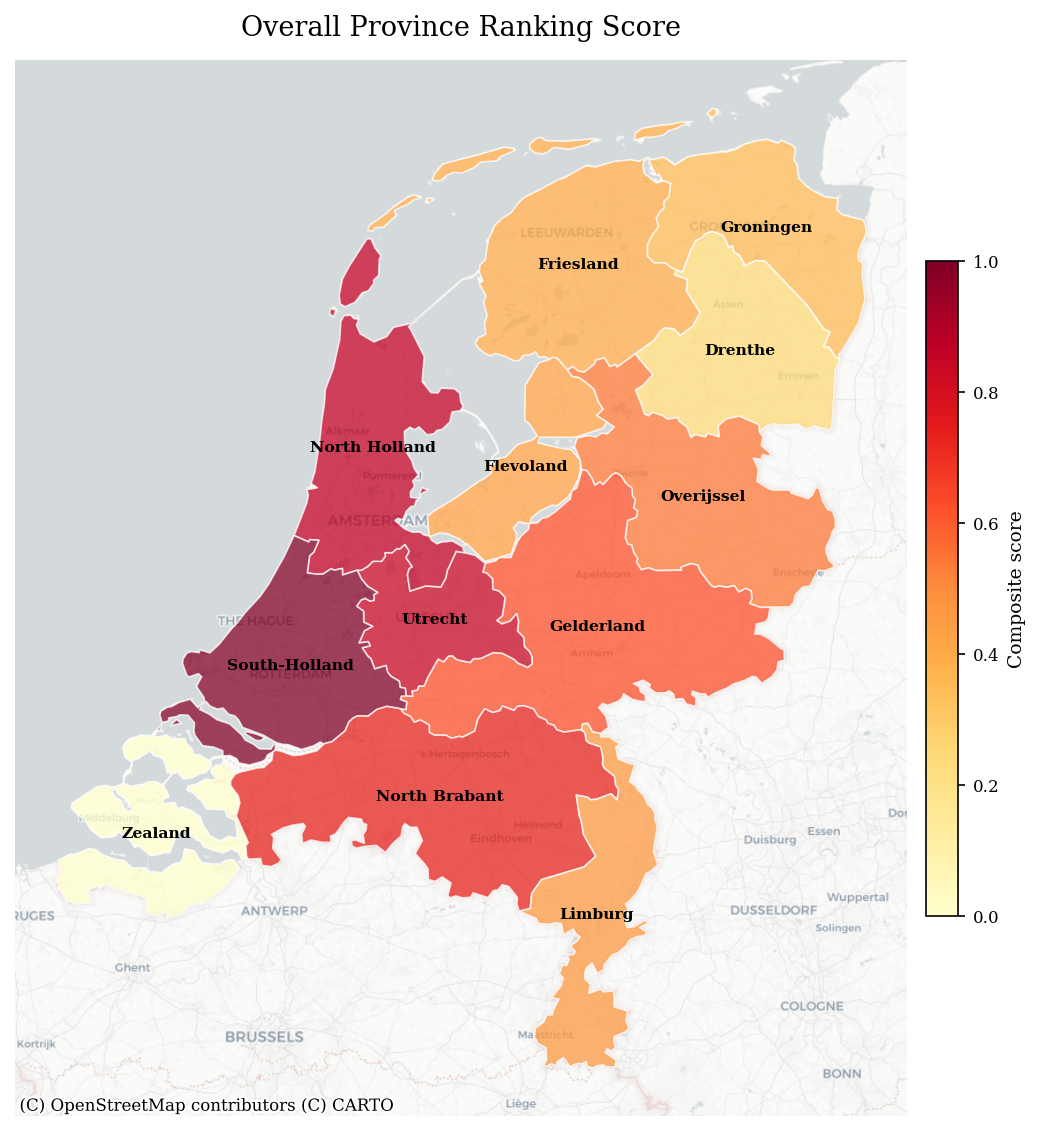

In [20]:
province_rank = compute_province_ranking(results_all)

plot_province_ranking_map(province_rank, save_path=str(FIG_DIR / "fig_province_ranking_map"),)

# 3. External Transferability <a class="anchor" id="external"></a>

## 3.1 Portuguese Travel Diaries Generation <a class="anchor" id="gene"></a>

### Full Generation to compare with NL Synthetic popylation (570 agents)

In [ ]:
#Full
results_pt_full = run_generation_pipeline_portugal(
    persona_objects=persona_objects,
    patterns=patterns,
    output_file="Json_files/trajectories_portugal_weekday_full.json",
    n_per_group=5,
    provider="groq_generation",
    context_condition="full",
)

### Prompt Sensitivity Ablation 

#### Small Full 

In [16]:
results_pt_full_small = run_generation_pipeline_portugal(
    persona_objects=persona_objects,
    patterns=patterns,
    output_file="Json_files/trajectories_portugal_weekday_full_small.json",
    n_per_group=2,
    provider="groq_generation",
    context_condition="full",
)

[1/113] SKIP homemaker | 65+ | weekday (already 2)
[2/113] SKIP employed | 51-66 | weekday | Income=Above median (already 2)
[3/113] SKIP employed | 51-66 | weekday | Income=Below median (already 2)
[4/113] SKIP employed | 51-66 | weekday | Income=High income (already 2)
[5/113] SKIP employed | 51-66 | weekday | Income=Low income (already 2)
[6/113] SKIP employed | 51-66 | weekday | Income=Median (already 2)
[7/113] SKIP inactive | 51-66 | weekday | Income=Above median (already 2)
[8/113] SKIP inactive | 51-66 | weekday | Income=Below median (already 2)
[9/113] SKIP inactive | 51-66 | weekday | Income=High income (already 2)
[10/113] SKIP inactive | 51-66 | weekday | Income=Low income (already 2)
[11/113] SKIP inactive | 51-66 | weekday | Income=Median (already 2)
[12/113] SKIP employed | 36-40 | weekday | Income=Above median (already 2)
[13/113] SKIP employed | 36-40 | weekday | Income=Below median (already 2)
[14/113] SKIP employed | 36-40 | weekday | Income=High income (already 2)
[

#### No commuting

In [17]:
results_pt_no_commuting = run_generation_pipeline_portugal(
    persona_objects=persona_objects,
    patterns=patterns,
    output_file="Json_files/trajectories_portugal_weekday_no_commuting.json",
    n_per_group=2,
    provider="groq_generation",
    context_condition="no_commuting",
)

[1/113] homemaker | 65+ | weekday — generating 2
  syn_pt_weekday_0001 
  syn_pt_weekday_0002 [ZERO_TRIP]
  -> saved (2 total for homemaker | 65+ | weekday)
[2/113] employed | 51-66 | weekday | Income=Above median — generating 2
  syn_pt_weekday_0003 
  syn_pt_weekday_0004 
  -> saved (2 total for employed | 51-66 | weekday | Income=Above median)
[3/113] employed | 51-66 | weekday | Income=Below median — generating 2
  syn_pt_weekday_0005 
  syn_pt_weekday_0006 
  -> saved (2 total for employed | 51-66 | weekday | Income=Below median)
[4/113] employed | 51-66 | weekday | Income=High income — generating 2
  syn_pt_weekday_0007 
  syn_pt_weekday_0008 [ZERO_TRIP]
  -> saved (2 total for employed | 51-66 | weekday | Income=High income)
[5/113] employed | 51-66 | weekday | Income=Low income — generating 2
  syn_pt_weekday_0009 
  syn_pt_weekday_0010 [ZERO_TRIP]
  -> saved (2 total for employed | 51-66 | weekday | Income=Low income)
[6/113] employed | 51-66 | weekday | Income=Median — genera

#### Minimal

In [20]:
results_pt_minimal = run_generation_pipeline_portugal(
    persona_objects=persona_objects,
    patterns=patterns,
    output_file="Json_files/trajectories_portugal_weekday_minimal.json",
    n_per_group=2,
    provider="groq_generation",
    context_condition="minimal",
)

[1/113] homemaker | 65+ | weekday — generating 2
  syn_pt_weekday_0001 
  syn_pt_weekday_0002 [ZERO_TRIP]
  -> saved (2 total for homemaker | 65+ | weekday)
[2/113] employed | 51-66 | weekday | Income=Above median — generating 2
  syn_pt_weekday_0003 
  syn_pt_weekday_0004 
  -> saved (2 total for employed | 51-66 | weekday | Income=Above median)
[3/113] employed | 51-66 | weekday | Income=Below median — generating 2
  syn_pt_weekday_0005 
  syn_pt_weekday_0006 
  -> saved (2 total for employed | 51-66 | weekday | Income=Below median)
[4/113] employed | 51-66 | weekday | Income=High income — generating 2
  syn_pt_weekday_0007 
  syn_pt_weekday_0008 [ZERO_TRIP]
  -> saved (2 total for employed | 51-66 | weekday | Income=High income)
[5/113] employed | 51-66 | weekday | Income=Low income — generating 2
  syn_pt_weekday_0009 
  syn_pt_weekday_0010 [ZERO_TRIP]
  -> saved (2 total for employed | 51-66 | weekday | Income=Low income)
[6/113] employed | 51-66 | weekday | Income=Median — genera

#### Strict prompt 

In [12]:
### Update with nre files after minimal 
results_pt_strict_no_cycling = run_generation_pipeline_portugal(
    persona_objects=persona_objects,
    patterns=patterns,
    output_file="Json_files/trajectories_portugal_weekday_strict.json",
    n_per_group=2,
    provider="groq_generation",
    context_condition="strict_no_cycling",
)

[1/113] homemaker | 65+ | weekday — generating 2
  syn_pt_weekday_0001 
  syn_pt_weekday_0002 [ZERO_TRIP]
  -> saved (2 total for homemaker | 65+ | weekday)
[2/113] employed | 51-66 | weekday | Income=Above median — generating 2
  syn_pt_weekday_0003 
  syn_pt_weekday_0004 
  -> saved (2 total for employed | 51-66 | weekday | Income=Above median)
[3/113] employed | 51-66 | weekday | Income=Below median — generating 2
  syn_pt_weekday_0005 
  syn_pt_weekday_0006 
  -> saved (2 total for employed | 51-66 | weekday | Income=Below median)
[4/113] employed | 51-66 | weekday | Income=High income — generating 2
  syn_pt_weekday_0007 
  syn_pt_weekday_0008 [ZERO_TRIP]
  -> saved (2 total for employed | 51-66 | weekday | Income=High income)
[5/113] employed | 51-66 | weekday | Income=Low income — generating 2
  syn_pt_weekday_0009 
  syn_pt_weekday_0010 [ZERO_TRIP]
  -> saved (2 total for employed | 51-66 | weekday | Income=Low income)
[6/113] employed | 51-66 | weekday | Income=Median — genera

#### No ground truth

In [25]:
results_pt_no_ground_truth = run_generation_pipeline_portugal(
    persona_objects=persona_objects,
    patterns=patterns,
    output_file="Json_files/pt_ablations/trajectories_portugal_weekday_no_ground_truth.json",
    n_per_group=2,
    provider="groq_generation",
    context_condition="no_ground_truth",
)



[1/113] SKIP homemaker | 65+ | weekday (already 2)
[2/113] SKIP employed | 51-66 | weekday | Income=Above median (already 2)
[3/113] SKIP employed | 51-66 | weekday | Income=Below median (already 2)
[4/113] SKIP employed | 51-66 | weekday | Income=High income (already 2)
[5/113] SKIP employed | 51-66 | weekday | Income=Low income (already 2)
[6/113] SKIP employed | 51-66 | weekday | Income=Median (already 2)
[7/113] SKIP inactive | 51-66 | weekday | Income=Above median (already 2)
[8/113] SKIP inactive | 51-66 | weekday | Income=Below median (already 2)
[9/113] SKIP inactive | 51-66 | weekday | Income=High income (already 2)
[10/113] SKIP inactive | 51-66 | weekday | Income=Low income (already 2)
[11/113] SKIP inactive | 51-66 | weekday | Income=Median (already 2)
[12/113] SKIP employed | 36-40 | weekday | Income=Above median (already 2)
[13/113] SKIP employed | 36-40 | weekday | Income=Below median (already 2)
[14/113] SKIP employed | 36-40 | weekday | Income=High income (already 2)
[

In [17]:
results_pt_bare_location = run_generation_pipeline_portugal(
    persona_objects=persona_objects,
    patterns=patterns,
    output_file="Json_files/pt_ablations/trajectories_portugal_weekday_bare_location.json",
    n_per_group=2,
    provider="groq_generation",
    context_condition="bare_location",
)

[1/113] homemaker | 65+ | weekday — generating 2
  syn_pt_weekday_0001 
  syn_pt_weekday_0002 [ZERO_TRIP]
  -> saved (2 total for homemaker | 65+ | weekday)
[2/113] employed | 51-66 | weekday | Income=Above median — generating 2
  syn_pt_weekday_0003 
  syn_pt_weekday_0004 
  -> saved (2 total for employed | 51-66 | weekday | Income=Above median)
[3/113] employed | 51-66 | weekday | Income=Below median — generating 2
  syn_pt_weekday_0005 
  syn_pt_weekday_0006 
  -> saved (2 total for employed | 51-66 | weekday | Income=Below median)
[4/113] employed | 51-66 | weekday | Income=High income — generating 2
  syn_pt_weekday_0007 
  syn_pt_weekday_0008 [ZERO_TRIP]
  -> saved (2 total for employed | 51-66 | weekday | Income=High income)
[5/113] employed | 51-66 | weekday | Income=Low income — generating 2
  syn_pt_weekday_0009 
  syn_pt_weekday_0010 [ZERO_TRIP]
  -> saved (2 total for employed | 51-66 | weekday | Income=Low income)
[6/113] employed | 51-66 | weekday | Income=Median — genera

## 3.2 Results EDA <a class="anchor" id="eda"></a>

### NL vs PT shift Analysis

In [12]:
nl_records = load_syn_records("Json_files/variance/full_seed42.json")
pt_records = load_syn_records("Json_files/pt_ablations/trajectories_portugal_weekday_full.json")
nl_runs = prep_syntrav_run(nl_records)
pt_runs = prep_syntrav_run(pt_records)


In [13]:
compute_mode_shift_data(nl_records, pt_records)

(['Passenger car', 'On foot', 'Public transport', 'Non-electric bicycle'],
 [33.4, 25.9, 3.1, 24.7],
 [50.6, 34.6, 10.2, 4.3],
 [58.9, 23.0, 15.8, 0.5],
 {'Passenger car': 0.3339818417639429,
  'On foot': 0.2587548638132296,
  'Public transport': 0.0311284046692607,
  'Non-electric bicycle': 0.24708171206225682},
 {'Passenger car': 0.5064498037016265,
  'On foot': 0.34604598990465507,
  'Public transport': 0.10207515423443635,
  'Non-electric bicycle': 0.04262478968031408})

#### Mode Behaviour Shift

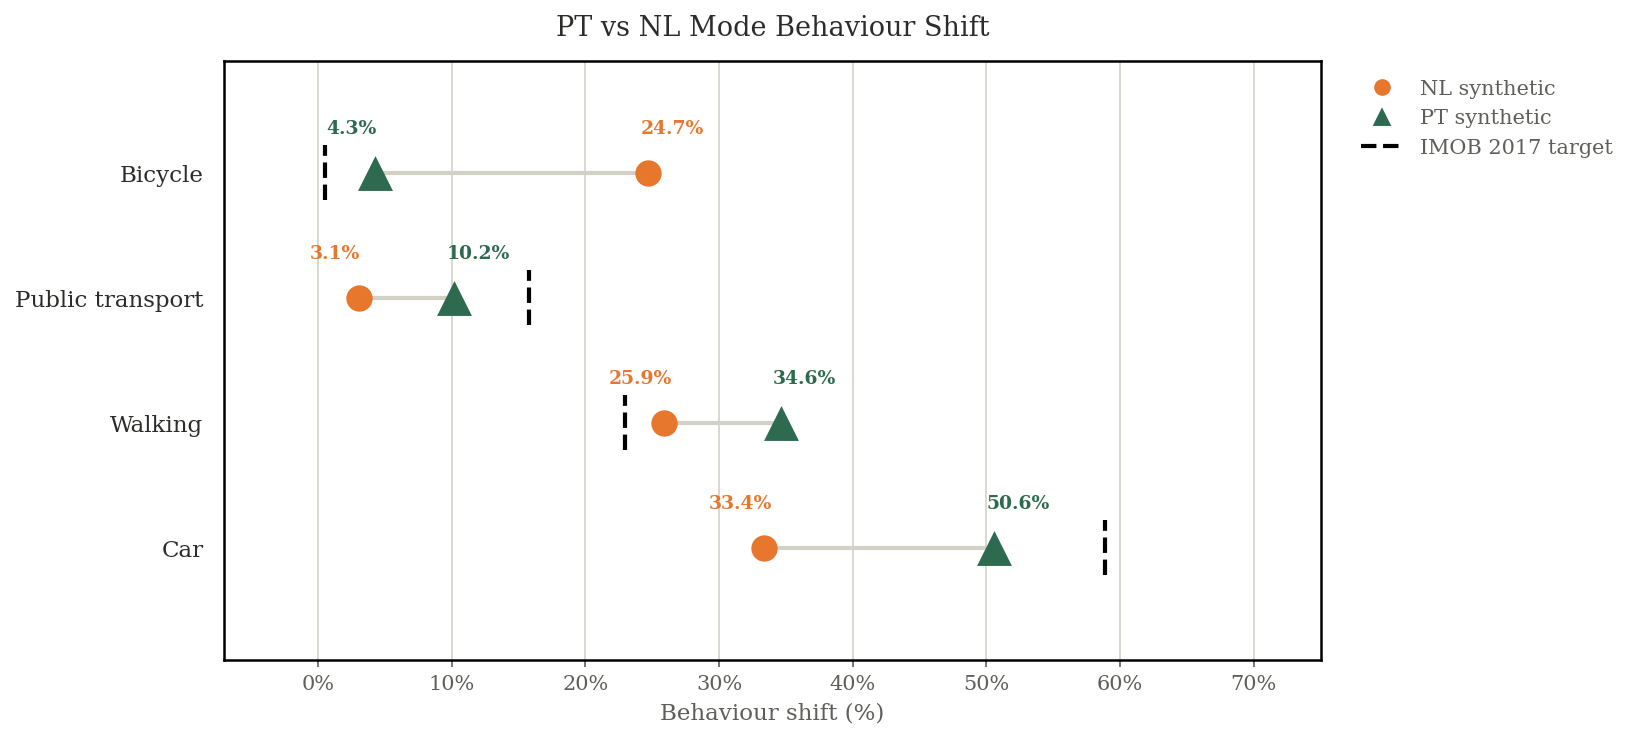

In [ ]:
modes, nl_vals, pt_vals, imob_vals, nl_ms, pt_ms = compute_mode_shift_data(nl_records, pt_records)
plot_mode_shift(modes, nl_vals, pt_vals, imob_vals,
                 save_path=str(FIG_DIR / "fig_mode_shift_nl_pt_imob"))


In [ ]:
plot_mode_share_by_purpose(nl_records, pt_records)

#### Distributions

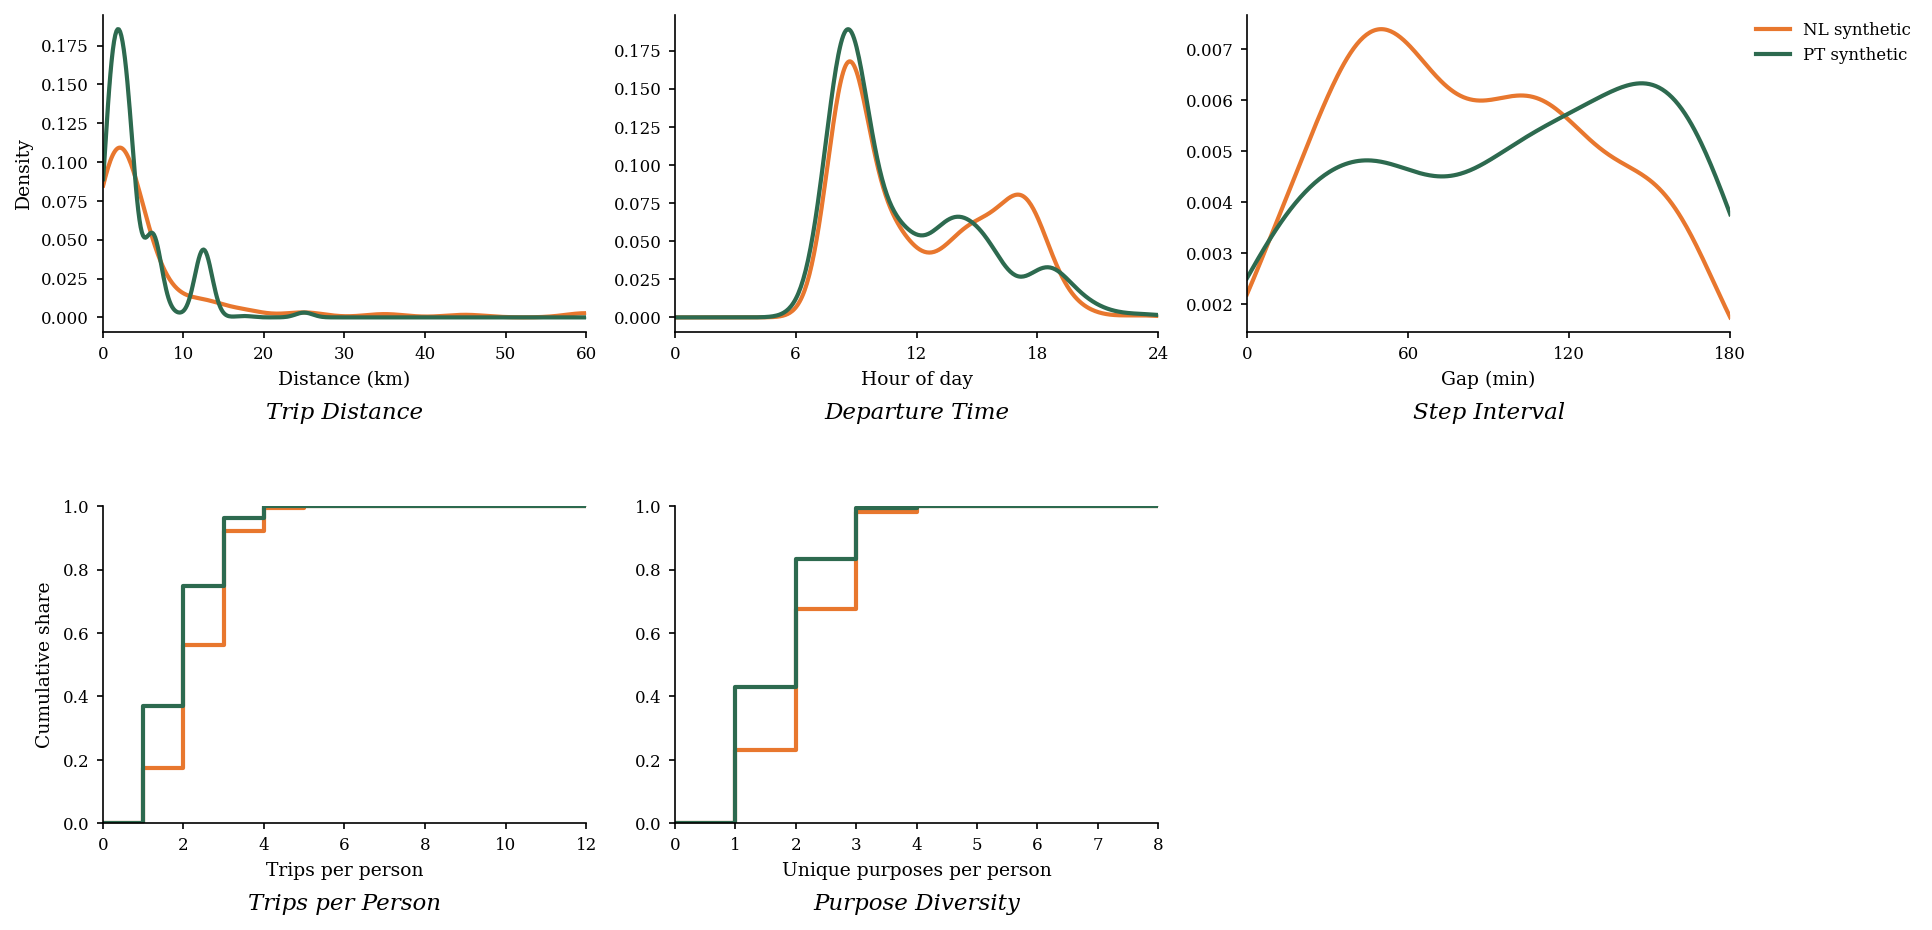

In [16]:
plot_combined_nl_pt(nl_runs, pt_runs,
                     save_path=str(FIG_DIR / "fig_combined_nl_pt"))

#### Spatiall Allocation on Portugal


isnt code missing here? 

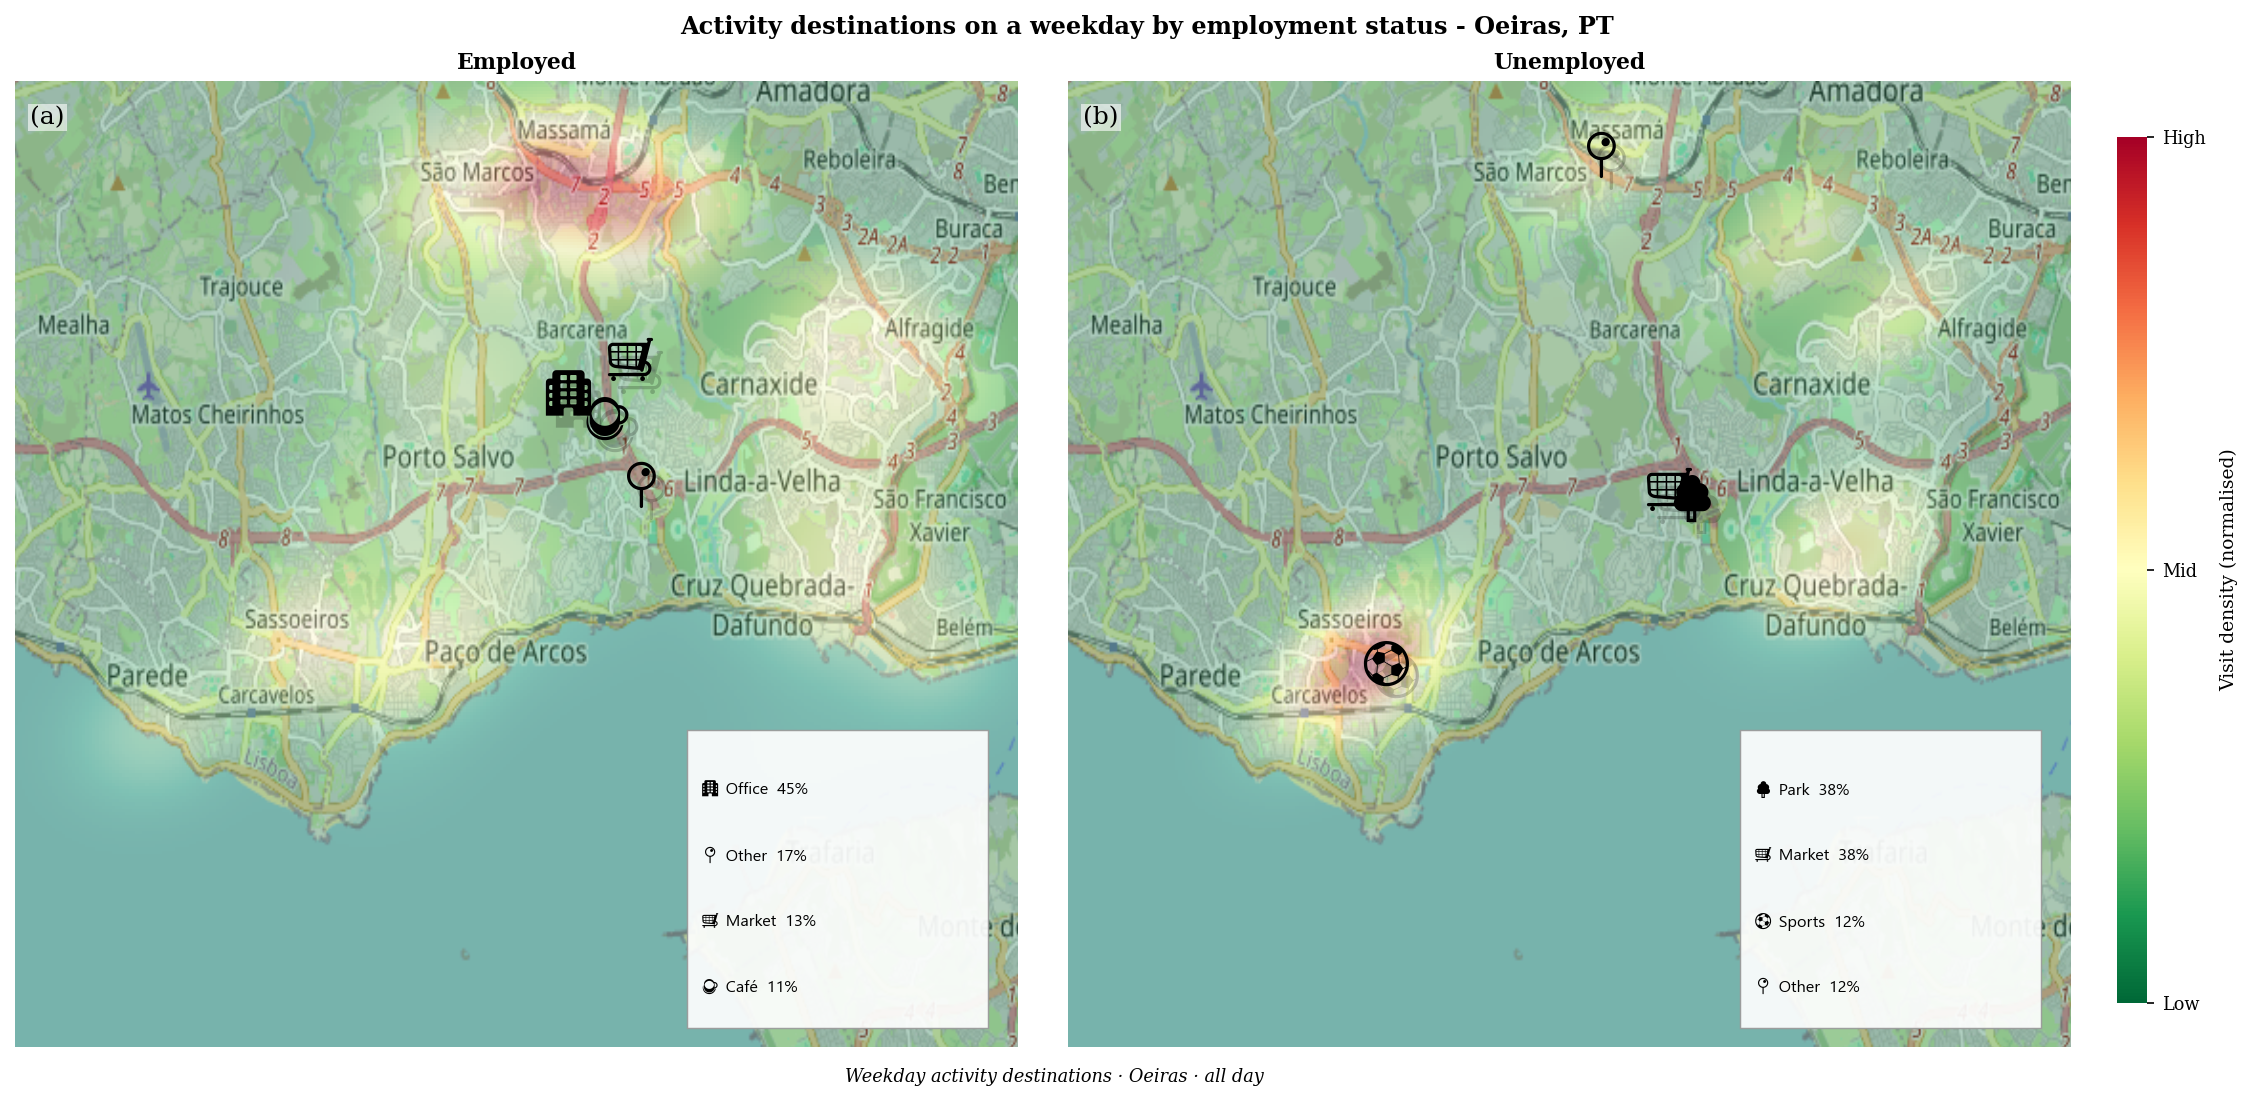

In [26]:
INCOMES = ["Low income", "Median", "High income", "Above median", "Below median"]
oeiras_records = load_oeiras_geo_records()

EMPLOYED_KEYS = [
    f"employed | {age} | weekday | Income={inc}"
    for age in ["26-30", "31-35", "36-40", "41-45", "46-50", "51-66"]
    for inc in INCOMES
]
UNEMPLOYED_KEYS = [
    "unemployed | 18-25 | weekday",
    "unemployed | 26-30 | weekday",
    # ...
]

plot_activity_intention_pt(
    oeiras_records,
    group_keys=[EMPLOYED_KEYS, UNEMPLOYED_KEYS],
    panel_titles=["Employed", "Unemployed"],
    fig_title="Activity destinations on a weekday by employment status - Oeiras, PT",
    save_path=str(FIG_DIR / "fig_activity_employed_unemployed_pt"),
)

### Sensitivity Analysis 

In [ ]:
ablation_records = load_pt_ablation_records()
ablation_shares   = compute_ablation_mode_shares(ablation_records)
print(ablation_shares)

print(rank_ablation_drivers(ablation_shares))    # which element moves behaviour most (vs full)
print(rank_ablation_realism(ablation_shares))    # which condition is closest to real IMOB data


                                             Car  Walking  Public transport  \
Minimal (no commuting, no cycling mention)  45.7     36.5               5.5   
No commuting stats                          54.0     31.5               8.5   
No cycling mention                          46.7     35.5               5.9   
Strict (explicit no-cycling directive)      58.2     27.5              14.2   
No modal ground truth                       49.9     29.5              16.7   
Full context                                50.1     34.0              10.3   

                                            Bicycle  
Minimal (no commuting, no cycling mention)     11.6  
No commuting stats                              5.8  
No cycling mention                             11.9  
Strict (explicit no-cycling directive)          0.1  
No modal ground truth                           3.5  
Full context                                    5.4  
Strict (explicit no-cycling directive)        23.8
Minimal (no commu

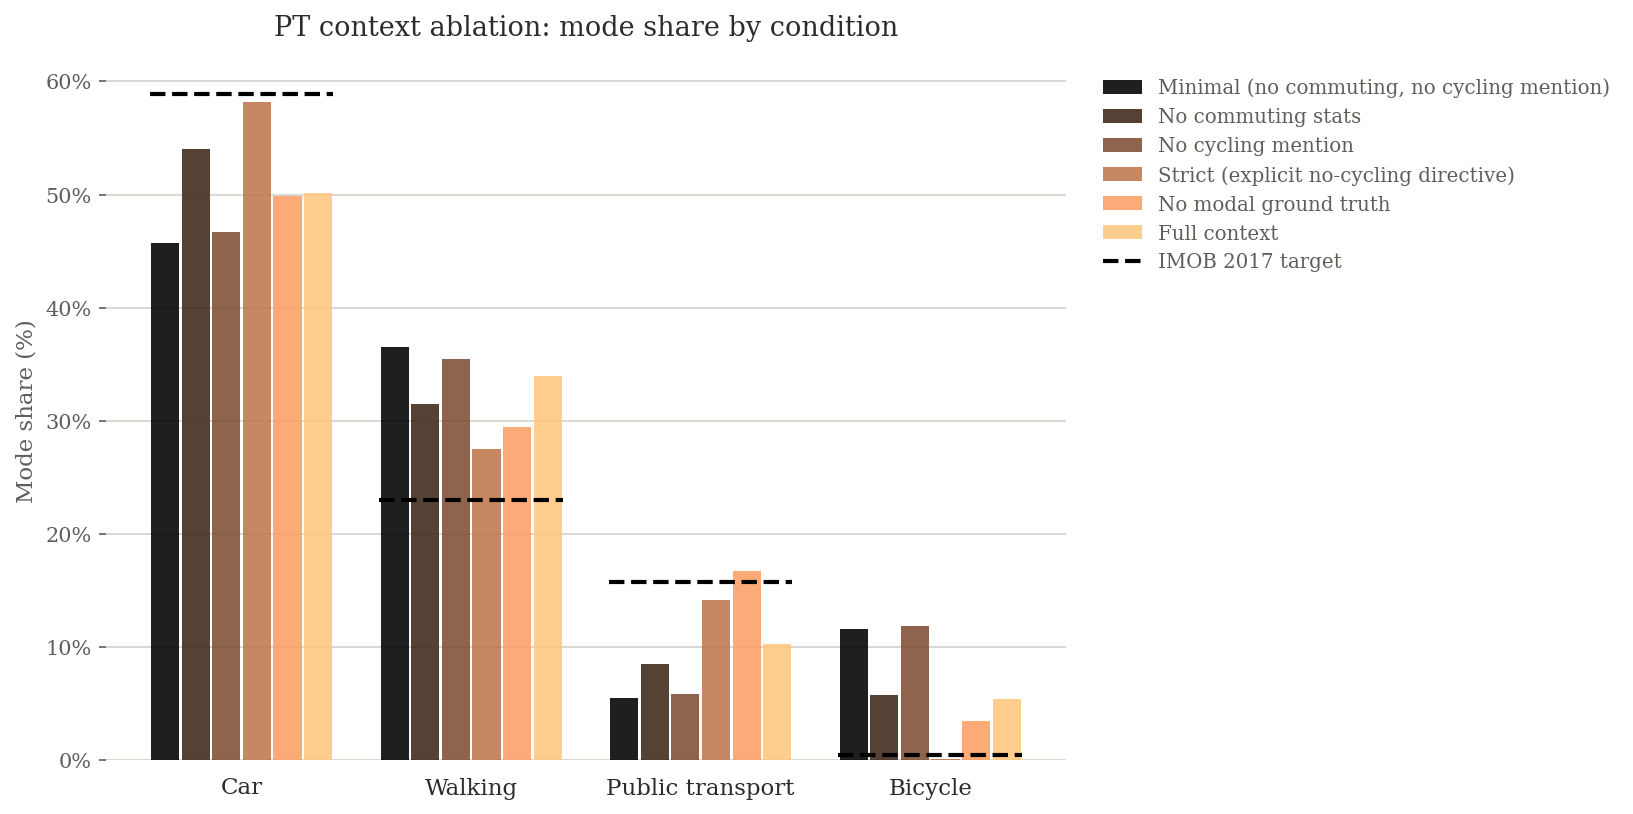

In [ ]:
plot_ablation_mode_shares(ablation_shares, save_path= None)

### Spatial Allocation Analysis

# 1: NL→PT directional shift

This one is purely synthetic vs synthetic — no ground truth needed. You pass NL features as "real" and PT features as
  "synthetic" into the existing JSD functions.